In [1]:
import geoplot as gplt
import geoplot.crs as gcrs
import geopandas as gpd

# Reading in the natural earth lowres data
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

In [8]:
world['area'] = world['geometry'].area

C:\Users\Aqwam\AppData\Local\Temp\ipykernel_10328\160731897.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world['area'] = world['geometry'].area


In [9]:
world

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,area
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",1.639511
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",76.301964
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",8.603984
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",1712.995228
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",1122.281921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,Admin-0 country,1,5,Republic of Serbia,SRB,0,2,Sovereign country,1,Republic of Serbia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((18.82982 45.90887, 18.82984 45.90888...",8.604719
173,Admin-0 country,1,6,Montenegro,MNE,0,2,Sovereign country,1,Montenegro,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((20.0707 42.58863, 19.80161 42.50009,...",1.479321
174,Admin-0 country,1,6,Kosovo,KOS,0,2,Disputed,1,Kosovo,...,Unrecognized,Admin-0 country,Unrecognized,Admin-0 country,Admin-0 country,Admin-0 country,Admin-0 country,Unrecognized,"POLYGON ((20.59025 41.85541, 20.52295 42.21787...",1.231641
175,Admin-0 country,1,5,Trinidad and Tobago,TTO,0,2,Sovereign country,1,Trinidad and Tobago,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((-61.68 10.76, -61.105 10.89, -60.895...",0.639000


AttributeError: 'MultiPolygon' object has no attribute 'exterior'

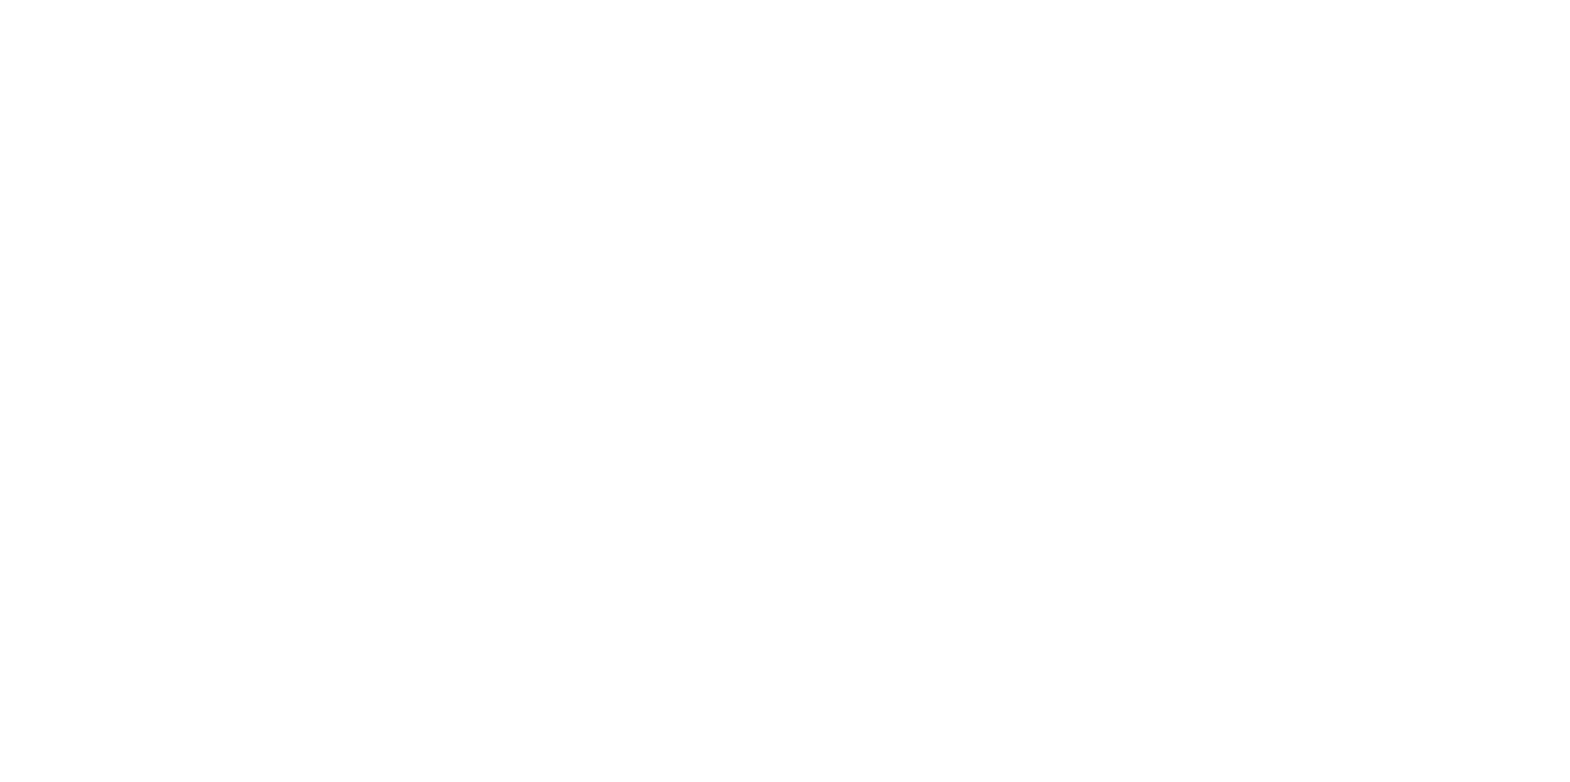

In [10]:
gplt.cartogram(world[world['CONTINENT']=="North America"], scale=world['area'],
    figsize=(20, 16))

C:\Users\Aqwam\AppData\Local\Temp\ipykernel_10328\3253307848.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  north_america['area'] = north_america.geometry.area


<Axes: >

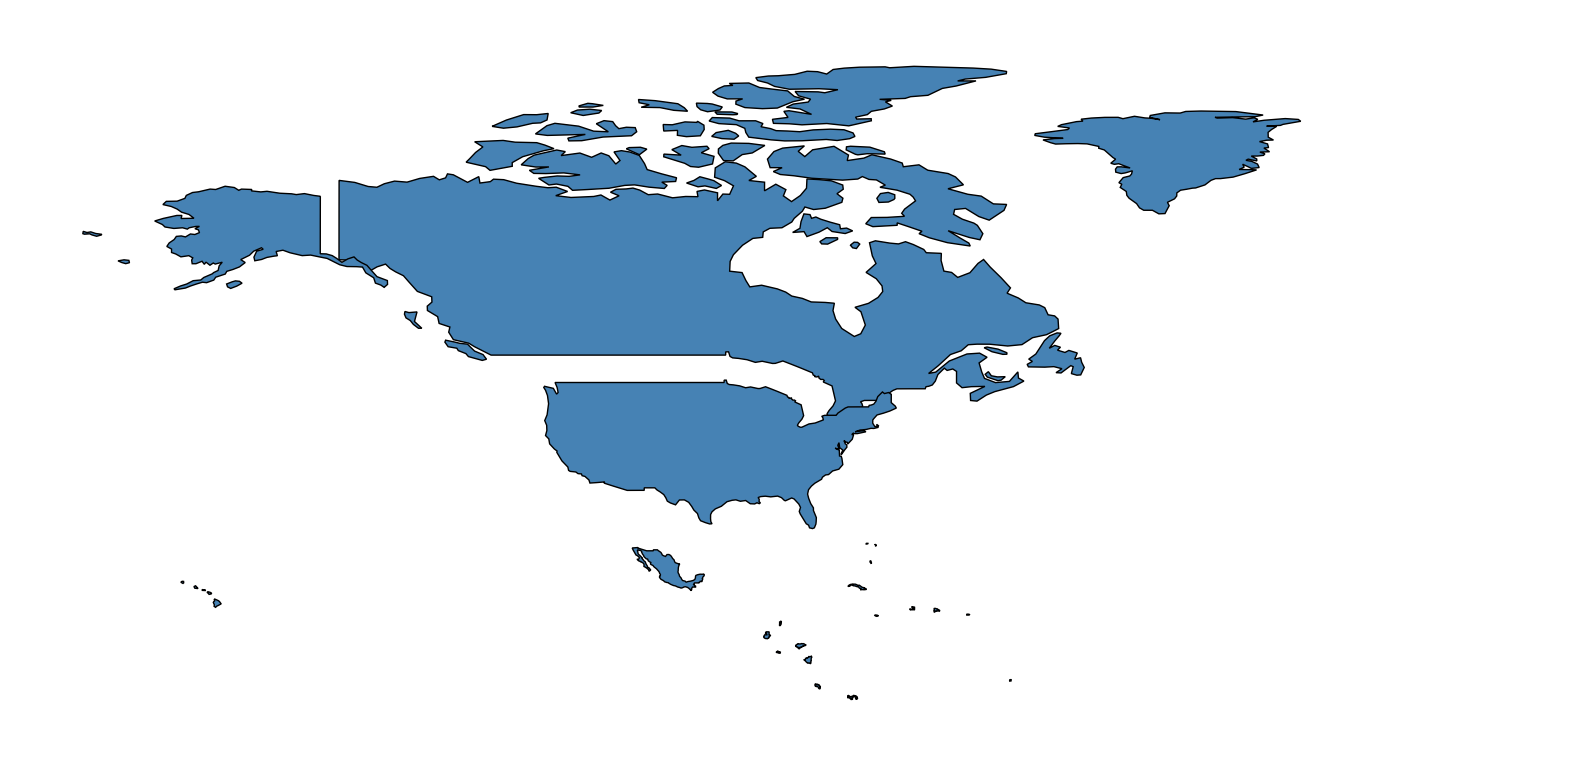

In [11]:
# 1. Isolate North America into its own separate dataframe copy
north_america = world[world['CONTINENT'] == "North America"].copy()

# 2. Calculate the area column directly within this subset (if not already present)
north_america['area'] = north_america.geometry.area

# 3. FIX THE MULTIPOLYGON BUG: Explode multi-part countries into individual single polygons
na_exploded = north_america.explode(index_parts=False)

# 4. Generate the cartogram using the column string name for 'scale'
gplt.cartogram(
    na_exploded, 
    scale='area',
    figsize=(20, 16)
)

<GeoAxes: >

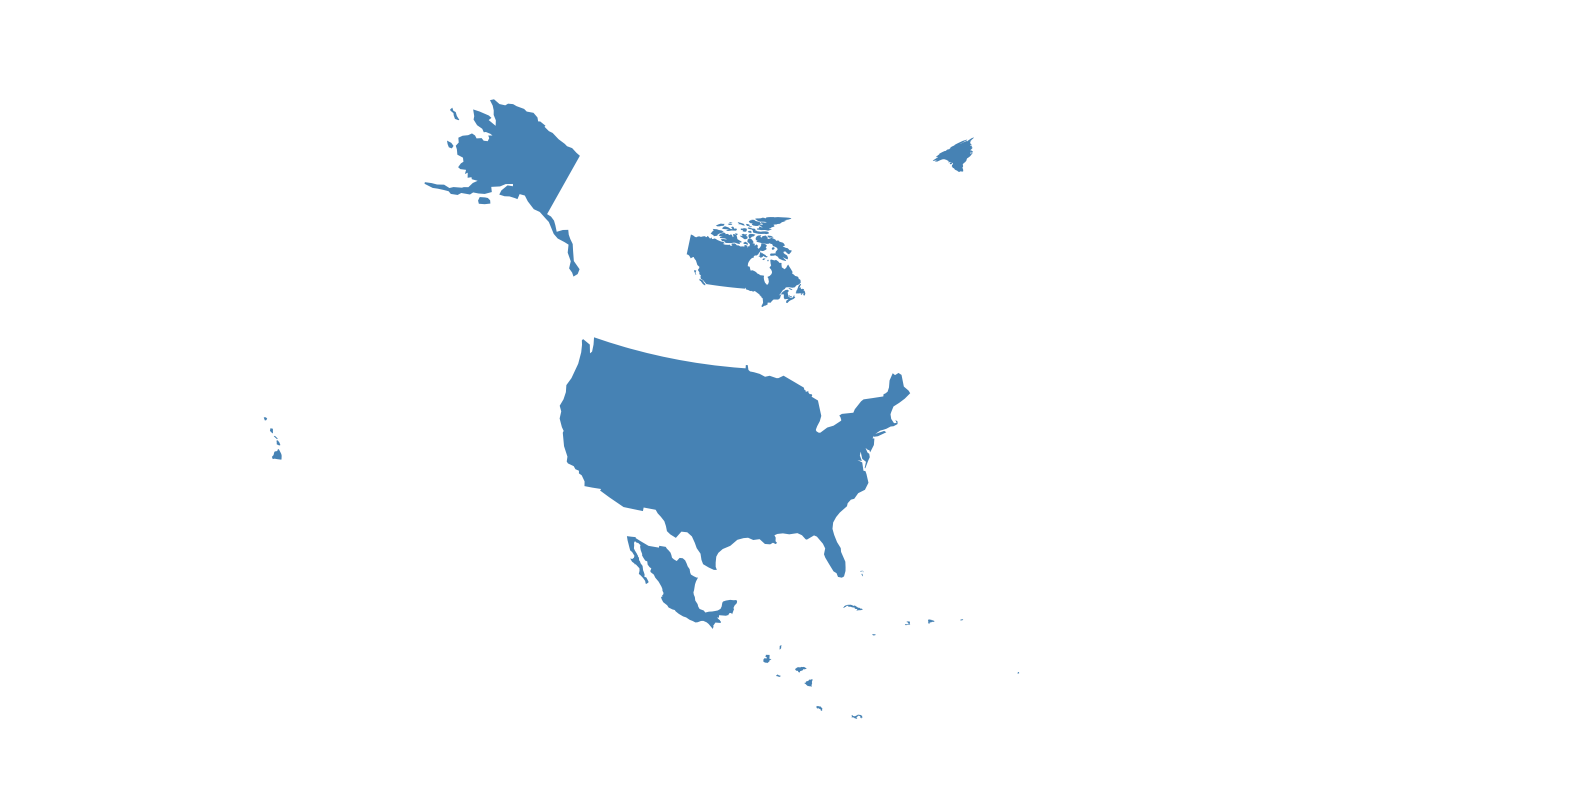

In [14]:
gplt.cartogram(world[world['CONTINENT']=="North America"], scale='POP_EST', projection=gcrs.AlbersEqualArea(),figsize=(20, 16))